In [46]:
!pip install ultralytics

In [48]:
import os
import cv2
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import shutil
from ultralytics import YOLO

In [49]:
train_images_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/training/images"
test_images_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/testing/images"
valid_images_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/validation/images"

In [50]:
train_ellipse_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/training/annfiles_ellipse"
test_ellipse_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/testing/annfiles_ellipse"
valid_ellipse_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/validation/annfiles_ellipse"

In [51]:
train_images_files=os.listdir(train_images_dir)
test_images_files=os.listdir(test_images_dir)
valid_images_files=os.listdir(valid_images_dir)

# Explore Sizes and Dimensions

In [52]:
print(len(train_images_files))
print(len(test_images_files))
print(len(valid_images_files))

200
50
50


In [53]:
dimensions=[]
for img_name in train_images_files[:10]:
    img_path=os.path.join(train_images_dir,img_name)
    img=cv2.imread(img_path)
    dimensions.append(img.shape)

print(dimensions)
        

[(661, 959, 3), (392, 640, 3), (663, 961, 3), (661, 959, 3), (661, 959, 3), (661, 959, 3), (661, 959, 3), (661, 959, 3), (787, 1137, 3), (661, 959, 3)]


In [54]:
dimensions=[]
for img_name in test_images_files[:10]:
    img_path=os.path.join(test_images_dir,img_name)
    img=cv2.imread(img_path)
    dimensions.append(img.shape)

print(dimensions)
        

[(661, 959, 3), (661, 959, 3), (661, 959, 3), (392, 640, 3), (661, 959, 3), (661, 959, 3), (448, 740, 3), (661, 959, 3), (661, 959, 3), (663, 961, 3)]


In [55]:
dimensions=[]
for img_name in valid_images_files[:10]:
    img_path=os.path.join(valid_images_dir,img_name)
    img=cv2.imread(img_path)
    dimensions.append(img.shape)

print(dimensions)
        

[(661, 959, 3), (661, 959, 3), (448, 740, 3), (448, 740, 3), (787, 1137, 3), (661, 959, 3), (661, 959, 3), (661, 959, 3), (663, 961, 3), (661, 959, 3)]


# Visualization

In [56]:
base_dir='/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart/training'
images_dir = os.path.join(base_dir, 'images')
masks_dir = os.path.join(base_dir, 'annfiles_mask')
ellipse_dir = os.path.join(base_dir, 'annfiles_ellipse')

file_id = '029'

# read image
img_path = os.path.join(images_dir, f'{file_id}.png')
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [57]:
def load_mask(name):
    for ext in ['.png', '.jpg', '.jpeg']:
        path = os.path.join(masks_dir, f'{name}{ext}')
        if os.path.exists(path):
            return cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return None

mask_cardiac = load_mask(f'{file_id}-cardiac')
mask_thorax = load_mask(f'{file_id}-thorax')

In [58]:
h, w, _ = img.shape
combined_mask = np.zeros((h, w, 3), dtype=np.uint8)

if mask_cardiac is not None:
    combined_mask[mask_cardiac > 0] = [255, 0, 0] 
if mask_thorax is not None:
    combined_mask[mask_thorax > 0] = [0, 0, 255] 

In [59]:
img_with_ellipse = img.copy()
ellipse_path = os.path.join(ellipse_dir, f'{file_id}.txt')

if os.path.exists(ellipse_path):
    with open(ellipse_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 6:
            x_center = int(float(parts[0]))
            y_center = int(float(parts[1]))
            axis_major = int(float(parts[2])) 
            axis_minor = int(float(parts[3])) 
            angle = int(float(parts[4]))
            label = parts[5]
            
            color = (255, 0, 0) if label == 'cardiac' else (0, 0, 255)
            cv2.ellipse(img_with_ellipse, (x_center, y_center), (axis_major, axis_minor), angle, 0, 360, color, 3)


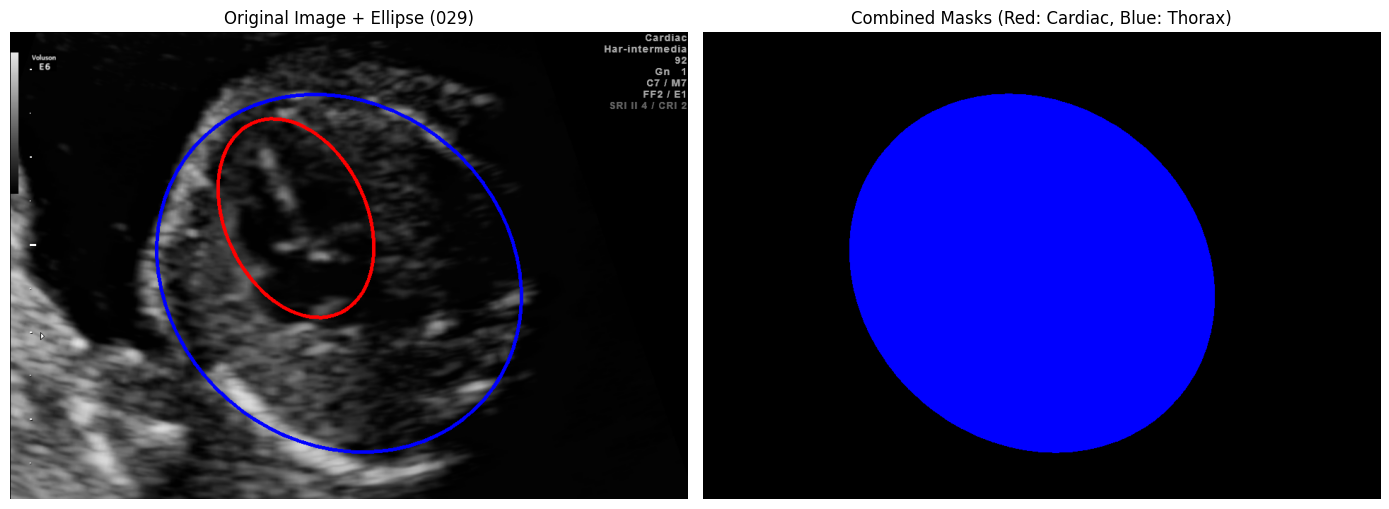

In [60]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_with_ellipse)
plt.title(f"Original Image + Ellipse ({file_id})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(combined_mask)
plt.title(f"Combined Masks (Red: Cardiac, Blue: Thorax)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Modeling

## Prepare Data to Yolo Format

In [61]:
# Data Directory and Folders
dataset_dir="/kaggle/input/datasets/emanyasserelnaggar/nabd-fetal-heart"
folders=['training','validation','testing']



In [62]:
# Yolo directory and Folders

base_yolo_dir='/kaggle/working/yolo_dataset'
os.makedirs(base_yolo_dir,exist_ok=True)

In [63]:
# Convert mask to Yolo Format

def mask_to_yolo_polygon(mask_path,img_w,img_h):
    # Read Mask
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    contours,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    polygons=[]
    for contour in contours:
        hull = cv2.convexHull(contour)
        epsilon = 0.002 * cv2.arcLength(hull,True)
        approx=cv2.approxPolyDP(hull,epsilon,True)

        if len(approx)<3:
            continue
        polygon_coord=[]
        for point in approx:
            x,y=point[0]
            polygon_coord.append(f"{x / img_w:.6f} {y / img_h:.6f}")
        polygons.append(" ".join(polygon_coord))
    return polygons

In [64]:
for folder in folders:
    yolo_folder=""
    if folder=="training":
        yolo_folder='train'
    elif folder=="validation":
        yolo_folder='val'
    elif folder=="testing":
        yolo_folder='test'
        
    new_img_dir = os.path.join(base_yolo_dir, 'images', yolo_folder)
    new_lbl_dir = os.path.join(base_yolo_dir, 'labels', yolo_folder)
    os.makedirs(new_img_dir, exist_ok=True)
    os.makedirs(new_lbl_dir, exist_ok=True)
    
    current_img_dir = os.path.join(dataset_dir, folder, 'images')
    current_msk_dir = os.path.join(dataset_dir, folder, 'annfiles_mask')
    
    if not os.path.exists(current_img_dir):
        continue
        
    img_files = [f for f in os.listdir(current_img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    print(f"processing {yolo_folder} in len {len(img_files)}")
    
    for img_name in img_files:
        file_id = os.path.splitext(img_name)[0]
        
        src_img_path = os.path.join(current_img_dir, img_name)
        img = cv2.imread(src_img_path)
        if img is None:
            continue
        img_h, img_w, _ = img.shape
        
        dst_img_path = os.path.join(new_img_dir, img_name)
        shutil.copy(src_img_path, dst_img_path)
        
        yolo_lines = []
        
        cardiac_mask_path = os.path.join(current_msk_dir, f"{file_id}-cardiac.png")
        if not os.path.exists(cardiac_mask_path):
            cardiac_mask_path = os.path.join(current_msk_dir, f"{file_id}-cardiac.jpg")
            
        if os.path.exists(cardiac_mask_path):
            polys = mask_to_yolo_polygon(cardiac_mask_path, img_w, img_h)
            for poly in polys:
                yolo_lines.append(f"0 {poly}") 
                
        thorax_mask_path = os.path.join(current_msk_dir, f"{file_id}-thorax.png")
        if not os.path.exists(thorax_mask_path):
            thorax_mask_path = os.path.join(current_msk_dir, f"{file_id}-thorax.jpg")
            
        if os.path.exists(thorax_mask_path):
            polys = mask_to_yolo_polygon(thorax_mask_path, img_w, img_h)
            for poly in polys:
                yolo_lines.append(f"1 {poly}")
                
        dst_lbl_path = os.path.join(new_lbl_dir, f"{file_id}.txt")
        with open(dst_lbl_path, 'w') as f:
            f.write("\n".join(yolo_lines))

print("finish")

processing train in len 200
processing val in len 50
processing test in len 50
finish


## Test Segmentation

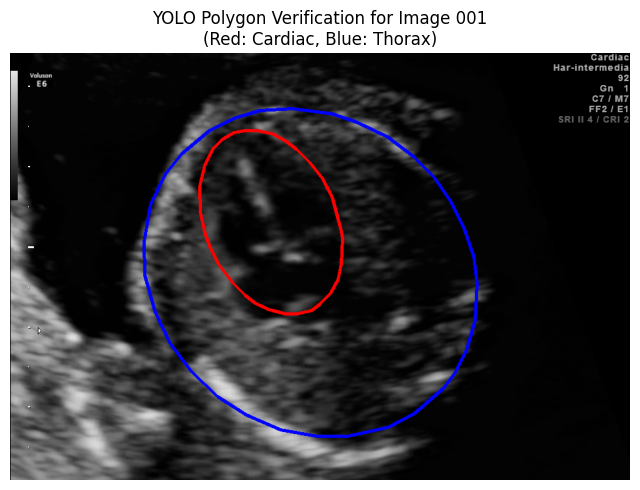

In [65]:
# test on image 1
image_path="/kaggle/working/yolo_dataset/images/train/029.png"
label_path="/kaggle/working/yolo_dataset/labels/train/029.txt"

img = cv2.imread(img_path)
img_h,img_w,_ = img.shape
img_test=img.copy()

with open(label_path,'r')as f:
    lines=f.readlines()
for line in lines:
    parts=line.strip().split()
    class_id=int(parts[0])
    coords=[float(x) for x in parts[1:]]
    # convert percentage to direct pixels
    points=[]
    for i in range(0,len(coords),2):
        x_pixel=int(coords[i]*img_w)
        y_pixel=int(coords[i+1]*img_h)
        points.append([x_pixel,y_pixel])
    pts=np.array(points,dtype=np.int32)
    pts=pts.reshape((-1,1,2))
    color = (0, 0, 255) if class_id == 0 else (255, 0, 0)
    cv2.polylines(img_test, [pts], isClosed=True, color=color, thickness=3)
img_test = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_test)
plt.title(f"YOLO Polygon Verification for Image 001\n(Red: Cardiac, Blue: Thorax)")
plt.axis('off')
plt.show()
    

## Yaml file

In [66]:
import yaml

yaml_data={
    'path':"/kaggle/working/yolo_dataset",
    'train':"images/train",
    "val":'images/val',
    'test':"images/test",
    'nc':2,
    'names':['cardiac','thorax']
}

yaml_path="/kaggle/working/data.yaml"
with open(yaml_path,'w')as f:
    yaml.dump(yaml_data,f,default_flow_style=False)

## train

In [67]:


model=YOLO("yolov8n-seg.pt")
results = model.train(
    data='/kaggle/working/data.yaml',     
    epochs=50,                             
    imgsz=640,                            
    batch=16,                              
    device=0,                              
    workers=2,                             
    degrees=15.0,                         
    flipud=0.5,                            
    fliplr=0.5,                            
    mosaic=1.0,
    hsv_v=0.4
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,

## Test

In [68]:
best_model="/kaggle/working/runs/segment/train-4/weights/best.pt"
model=YOLO(best_model)

In [69]:
from shapely.geometry import Polygon as ShapelyPolygon

In [70]:
def calculate_iou(poly1, poly2):
    try:
        p1 = ShapelyPolygon(poly1)
        p2 = ShapelyPolygon(poly2)
        if not p1.is_valid or not p2.is_valid:
            p1 = p1.buffer(0)
            p2 = p2.buffer(0)
        intersection = p1.intersection(p2).area
        union = p1.union(p2).area
        return intersection / union if union > 0 else 0
    except:
        return 0

In [71]:
def diagnostic_and_compare_pipeline(img_path, label_path, model):
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    
    img_h, img_w, _ = img.shape
    img_vis = img.copy()
    
    gt_polygons = {0: [], 1: []} 
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 3: continue
                cls_id = int(parts[0])
                coords = [float(x) for x in parts[1:]]
                pts = [(coords[i]*img_w, coords[i+1]*img_h) for i in range(0, len(coords), 2)]
                if len(pts) >= 3:
                    gt_polygons[cls_id].append(pts)

    results = model.predict(source=img_path, conf=0.25, verbose=False)
    result = results[0]
    
    pred_cardiac_xs, pred_thorax_xs = [], []
    pred_cardiac_poly, pred_thorax_poly = None, None
    
    if result.masks is not None:
        polygons = result.masks.xy
        classes = result.boxes.cls.cpu().numpy()
        
        for poly, cls_id in zip(polygons, classes):
            pts = np.array(poly, dtype=np.int32)
            if int(cls_id) == 0:
                pred_cardiac_xs.extend(pts[:, 0])
                pred_cardiac_poly = poly
                color = (0, 0, 255) 
            else:
                pred_thorax_xs.extend(pts[:, 0])
                pred_thorax_poly = poly
                color = (255, 0, 0) 
                
            cv2.polylines(img_vis, [pts.reshape((-1, 1, 2))], isClosed=True, color=color, thickness=3)
            
    cardiac_iou = calculate_iou(pred_cardiac_poly, gt_polygons[0][0]) if (pred_cardiac_poly is not None and gt_polygons[0]) else 0
    thorax_iou = calculate_iou(pred_thorax_poly, gt_polygons[1][0]) if (pred_thorax_poly is not None and gt_polygons[1]) else 0
    
    if len(pred_cardiac_xs) > 0 and len(pred_thorax_xs) > 0:
        heart_width = max(pred_cardiac_xs) - min(pred_cardiac_xs)
        thorax_width = max(pred_thorax_xs) - min(pred_thorax_xs)
        ctr_percentage = (heart_width / thorax_width) * 100
        diagnosis = "ALERT: Cardiomegaly" if (heart_width / thorax_width) > 0.50 else "Normal"
        
        return {
            'heart_width_px': round(heart_width, 2),
            'thorax_width_px': round(thorax_width, 2),
            'ctr_percentage': round(ctr_percentage, 2),
            'cardiac_iou_%': round(cardiac_iou * 100, 2),
            'thorax_iou_%': round(thorax_iou * 100, 2),
            'diagnosis': diagnosis
        }, img_vis

    return None, None

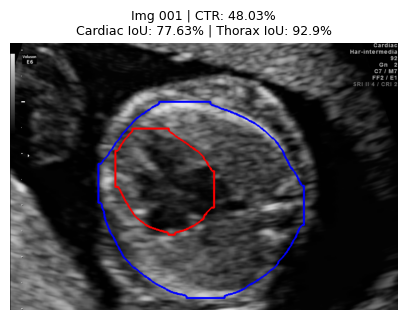

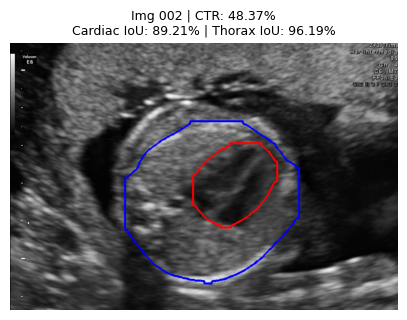

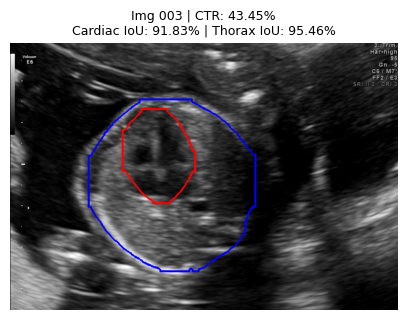

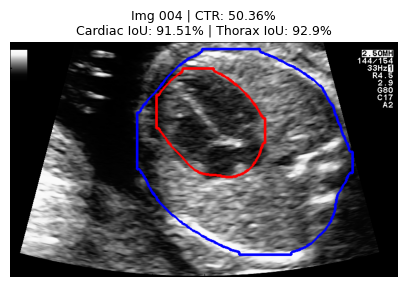

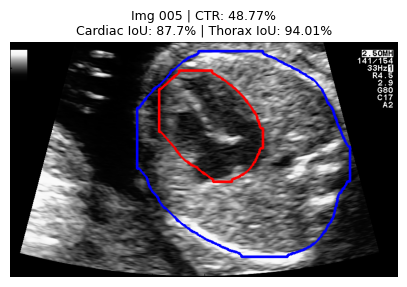

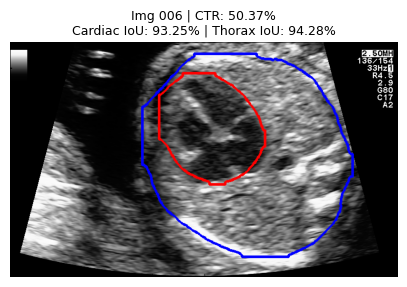

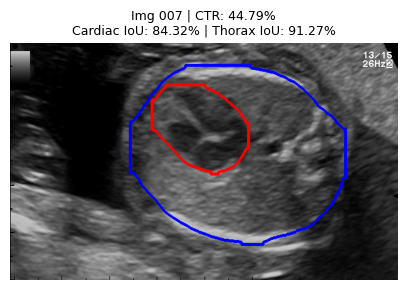

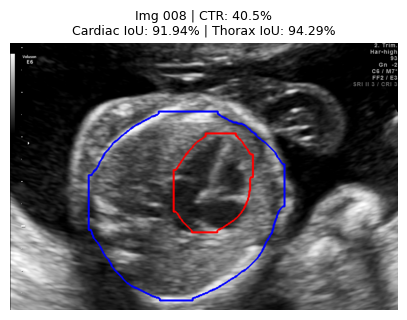

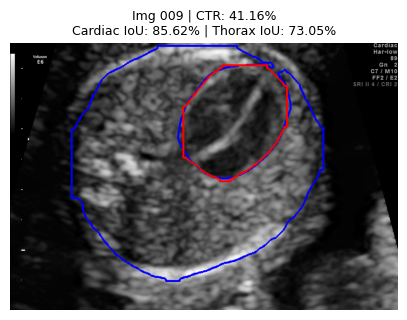

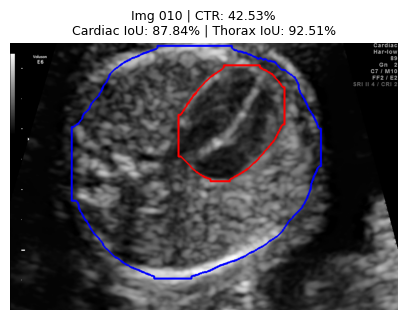

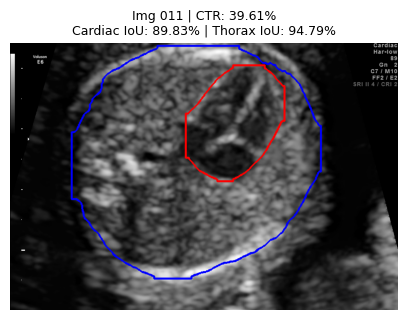

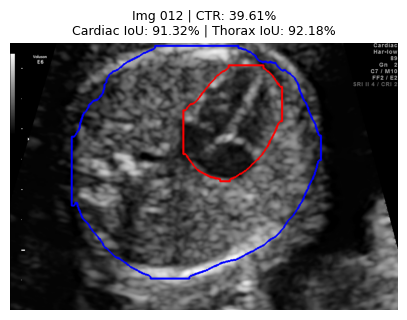

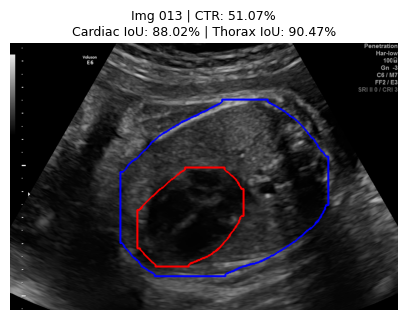

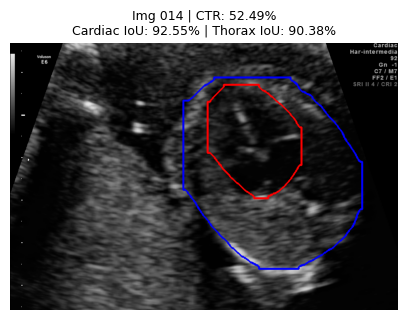

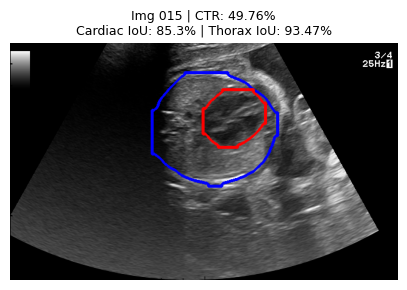

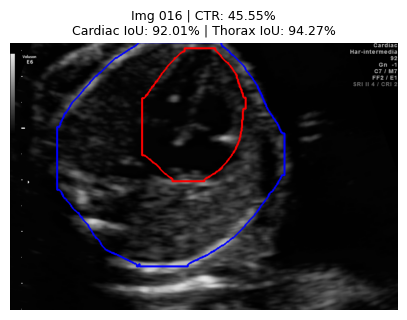

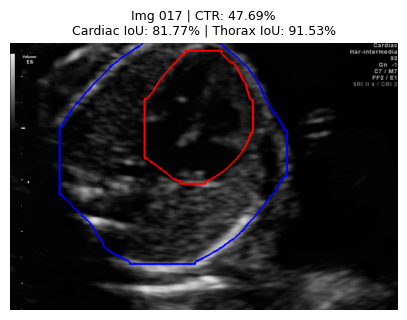

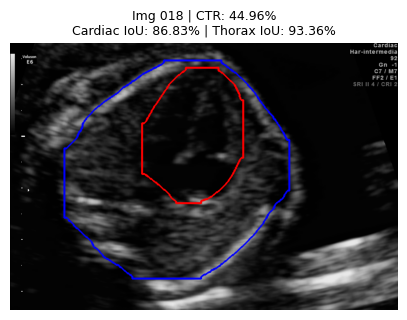

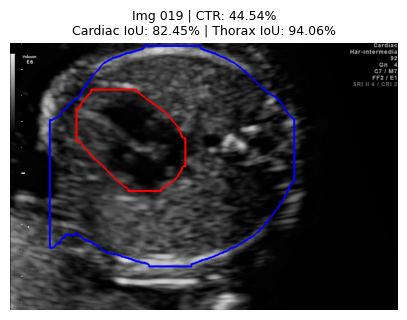

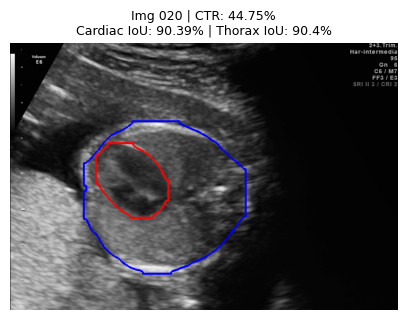

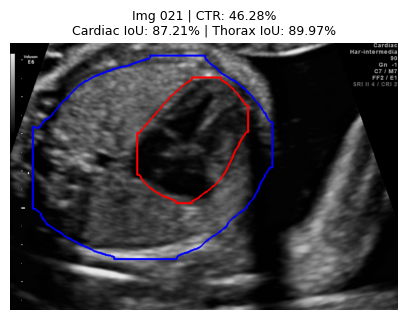

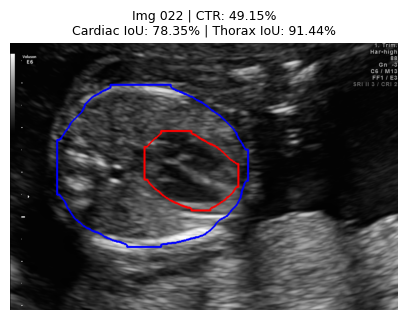

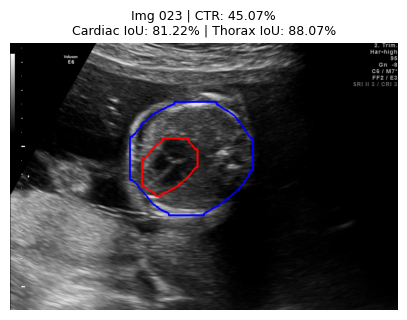

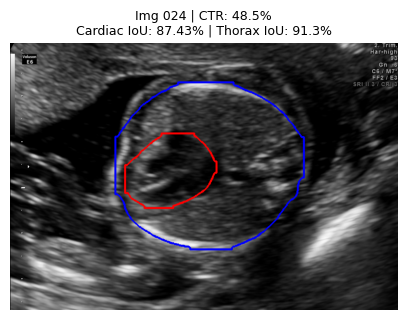

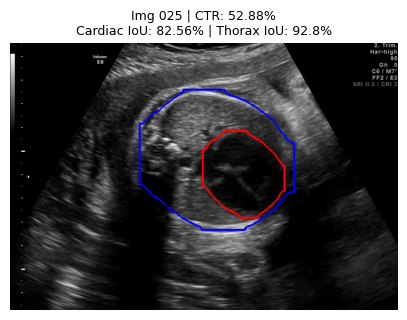

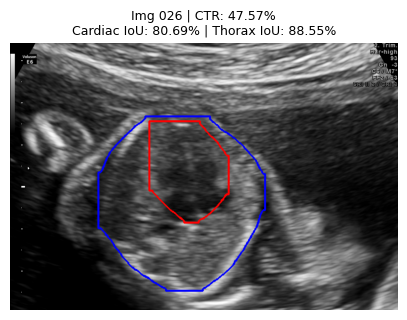

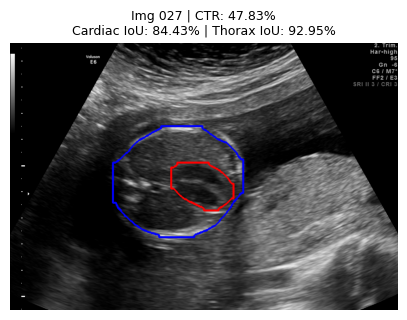

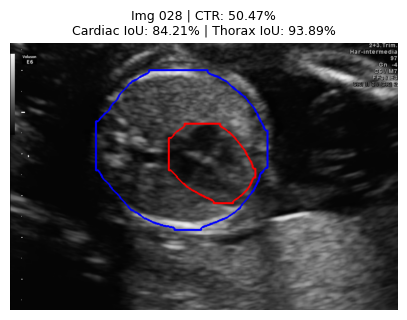

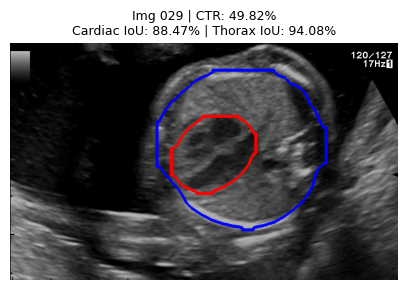

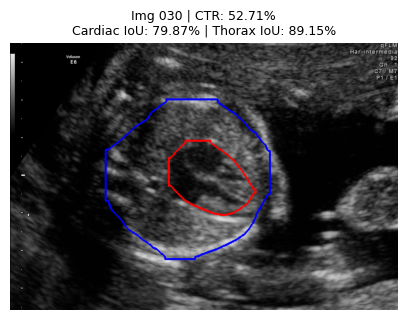

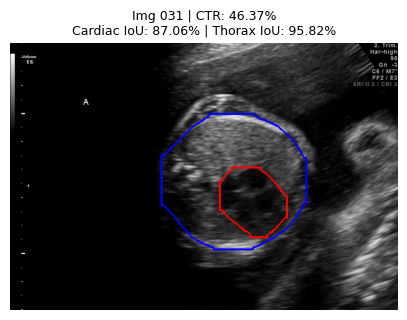

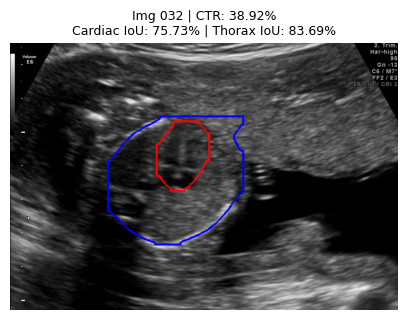

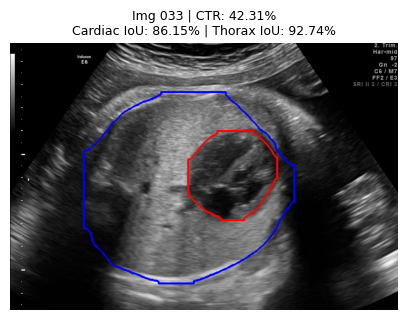

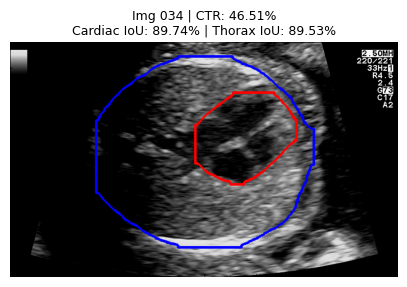

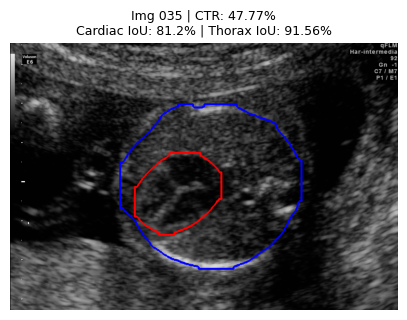

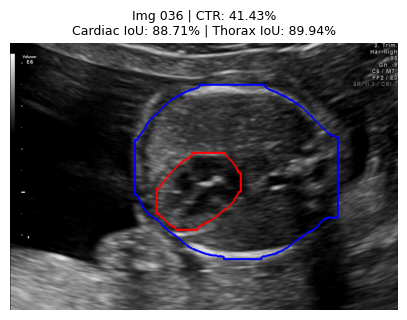

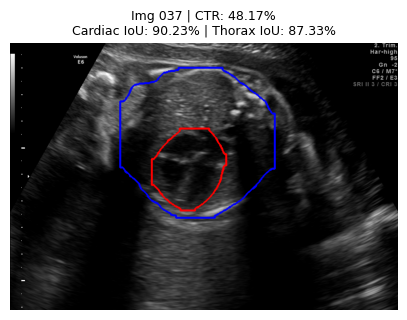

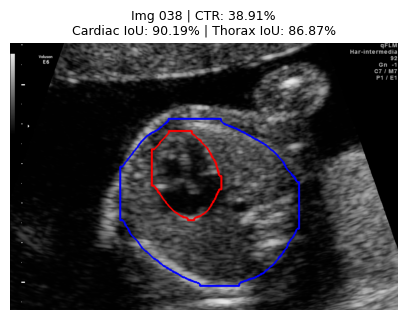

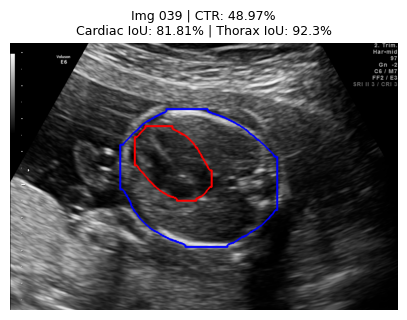

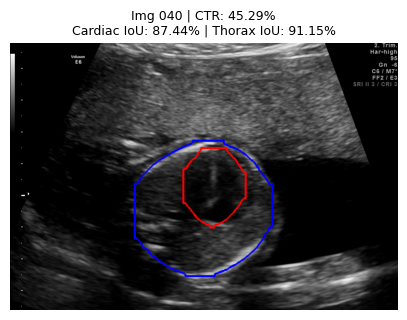

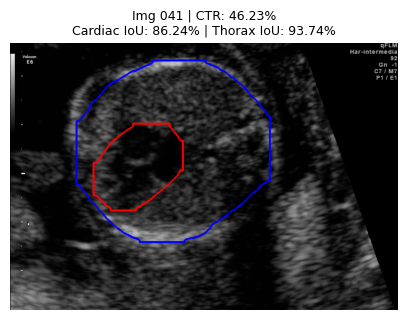

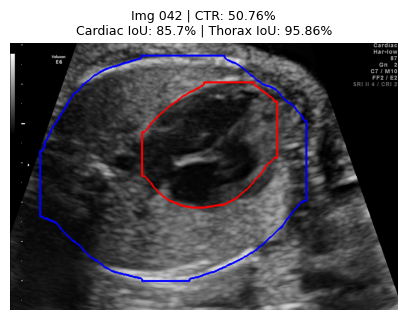

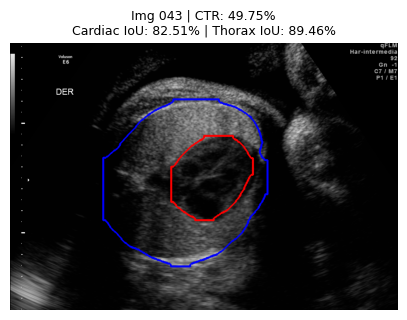

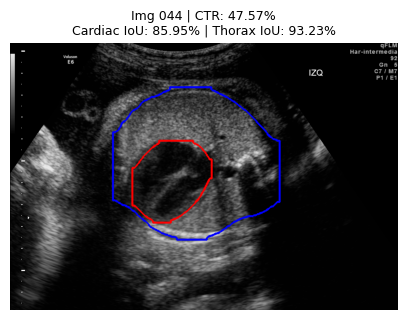

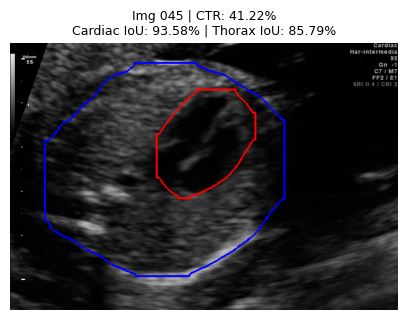

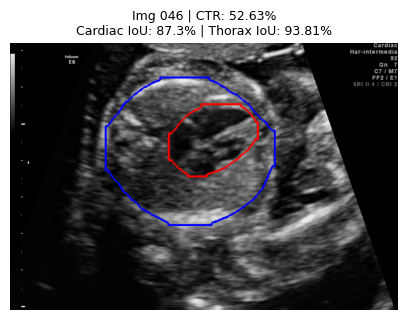

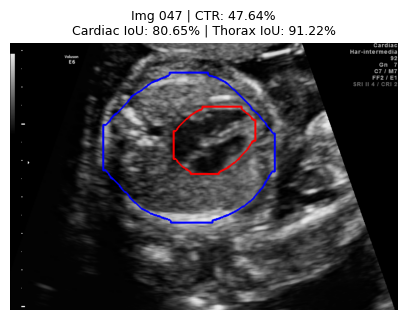

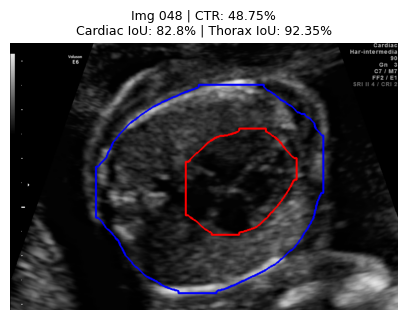

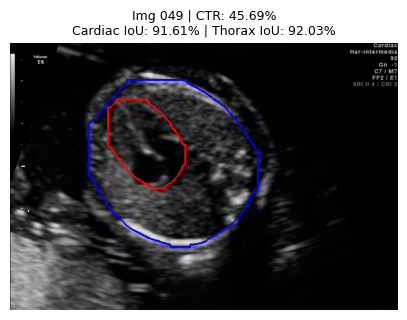

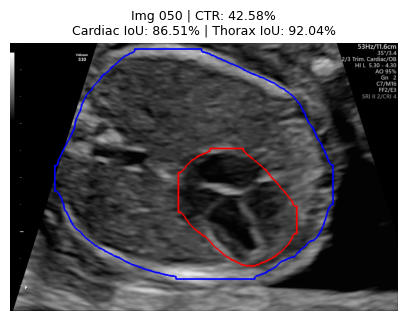

Average Cardiac IoU: 86.34%
Average Thoracic IoU: 91.49%


In [73]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd

test_images_dir = '/kaggle/working/yolo_dataset/images/test'
test_labels_dir = '/kaggle/working/yolo_dataset/labels/test'

output_images_dir = '/kaggle/working/test_test_photos'
os.makedirs(output_images_dir, exist_ok=True)

all_results = []

test_files = sorted([f for f in os.listdir(test_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])


for img_name in test_files:
    file_id = os.path.splitext(img_name)[0]
    img_path = os.path.join(test_images_dir, img_name)
    label_path = os.path.join(test_labels_dir, f"{file_id}.txt")
    
    metrics, final_img = diagnostic_and_compare_pipeline(img_path, label_path, model)
    
    if metrics is not None:
        metrics['image_id'] = file_id
        all_results.append(metrics)
        
        output_img_path = os.path.join(output_images_dir, f"{file_id}_eval.png")
        cv2.imwrite(output_img_path, final_img)
        
        final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(5, 5))
        plt.imshow(final_img_rgb)
        plt.title(f"Img {file_id} | CTR: {metrics['ctr_percentage']}%\nCardiac IoU: {metrics['cardiac_iou_%']}% | Thorax IoU: {metrics['thorax_iou_%']}%", fontsize=9)
        plt.axis('off')
        plt.show()

if all_results:
    df = pd.DataFrame(all_results)
    df_csv = df[['image_id', 'heart_width_px', 'thorax_width_px', 'ctr_percentage', 'cardiac_iou_%', 'thorax_iou_%', 'diagnosis']]
    df_csv.to_csv('/kaggle/working/nabd_fetal_ctr_results_with_compare.csv', index=False)
    
    avg_cardiac_iou = df['cardiac_iou_%'].mean()
    avg_thorax_iou = df['thorax_iou_%'].mean()
    
    print(f"Average Cardiac IoU: {avg_cardiac_iou:.2f}%")
    print(f"Average Thoracic IoU: {avg_thorax_iou:.2f}%")

In [74]:
output_zip_path = '/kaggle/working/nabd_fetal_runs'
directory_to_zip = '/kaggle/working/runs'
shutil.make_archive(output_zip_path, 'zip', directory_to_zip)

'/kaggle/working/nabd_fetal_runs.zip'

In [75]:
output_zip_path = '/kaggle/working/test_test_photos'
directory_to_zip = '/kaggle/working/test_test_photos'
shutil.make_archive(output_zip_path, 'zip', directory_to_zip)

'/kaggle/working/test_test_photos.zip'

In [81]:
output_zip_path = '/kaggle/working/nabd_fetal_dataset'
directory_to_zip = '/kaggle/working/yolo_dataset'
shutil.make_archive(output_zip_path, 'zip', directory_to_zip)

'/kaggle/working/nabd_fetal_dataset.zip'

# Unseen Data

In [ ]:
def diagnostic_unseen_save_pipeline(img_path, save_dir, model):
    img = cv2.imread(img_path)
    if img is None:
        return None, None
    
    img_h, img_w, _ = img.shape
    img_vis = img.copy()
    
    results = model.predict(source=img_path, conf=0.25, verbose=False)
    result = results[0]
    
    pred_cardiac_xs = []
    pred_thorax_xs = []
    
    if result.masks is not None:
        polygons = result.masks.xy
        classes = result.boxes.cls.cpu().numpy()
        
        for poly, cls_id in zip(polygons, classes):
            pts = np.array(poly, dtype=np.int32)
            if int(cls_id) == 0: 
                pred_cardiac_xs.extend(pts[:, 0])
                color = (0, 0, 255) 
            else: # Thorax
                pred_thorax_xs.extend(pts[:, 0])
                color = (255, 0, 0) 
                
            cv2.polylines(img_vis, [pts.reshape((-1, 1, 2))], isClosed=True, color=color, thickness=3)
            

    if len(pred_cardiac_xs) > 0 and len(pred_thorax_xs) > 0:
        heart_width = max(pred_cardiac_xs) - min(pred_cardiac_xs)
        thorax_width = max(pred_thorax_xs) - min(pred_thorax_xs)
        
        ctr_ratio = heart_width / thorax_width
        ctr_percentage = (heart_width / thorax_width) * 100
        
        if ctr_ratio > 0.60:
            diagnosis = "CRITICAL ALERT: Severe Cardiomegaly"
            alert_level = 2
        elif 0.50 < ctr_ratio <= 0.60:
            diagnosis = "WARNING: Borderline / Mild Cardiomegaly"
            alert_level = 1
        else:
            diagnosis = "Normal Cardiothoracic Ratio"
            alert_level = 0
            
        font = cv2.FONT_HERSHEY_SIMPLEX
        text = f"CTR: {ctr_percentage:.1f}% | LVL: {alert_level}"
        cv2.putText(img_vis, text, (15, 35), font, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        
        img_name = os.path.basename(img_path)
        save_path = os.path.join(save_dir, f"pred_{img_name}")
        cv2.imwrite(save_path, img_vis)
        
        return {
            'heart_width_px': round(heart_width, 2),
            'thorax_width_px': round(thorax_width, 2),
            'ctr_percentage': round(ctr_percentage, 2),
            'diagnosis': diagnosis,
            'alert_level': alert_level
        }

    return None



In [14]:
model = YOLO('/kaggle/input/models/emanyasserelnaggar/best-nabd-fetal/pytorch/default/1/best.pt')

unseen_images_dir = '/kaggle/input/datasets/emanyasserelnaggar/try-new-2/try_new_2' 

output_images_dir = '/kaggle/working/output_images'
os.makedirs(output_images_dir, exist_ok=True)

unseen_results = []
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
unseen_files = sorted([f for f in os.listdir(unseen_images_dir) if f.lower().endswith(valid_extensions)])

for img_name in unseen_files:
    img_path = os.path.join(unseen_images_dir, img_name)
    file_id = os.path.splitext(img_name)[0]
    
    metrics = diagnostic_unseen_save_pipeline(img_path, output_images_dir, model)
    
    if metrics is not None:
        metrics['image_id'] = file_id
        unseen_results.append(metrics)
    else:
        print(f"failed{file_id}")


if unseen_results:
    df_unseen = pd.DataFrame(unseen_results)
    df_unseen = df_unseen[['image_id', 'heart_width_px', 'thorax_width_px', 'ctr_percentage', 'diagnosis', 'alert_level']]
    df_unseen.to_csv('/kaggle/working/unseen_data_diagnosis_results.csv', index=False)

failedPatient00693_Plane6_1_of_2
failedPatient00712_Plane6_1_of_3
failedPatient00750_Plane6_1_of_1
failedPatient00757_Plane6_1_of_2
failedPatient00813_Plane6_1_of_4
failedPatient00813_Plane6_2_of_4
failedPatient00813_Plane6_3_of_4
failedPatient00813_Plane6_4_of_4
failedPatient00826_Plane6_1_of_5
failedPatient00858_Plane6_2_of_6
failedPatient00858_Plane6_3_of_6
failedPatient00877_Plane6_6_of_7
failedPatient00877_Plane6_7_of_7
failedPatient00952_Plane6_2_of_5
failedPatient00988_Plane6_1_of_1
failedPatient01031_Plane6_1_of_1
failedPatient01037_Plane6_2_of_2
failedPatient01078_Plane6_1_of_3
failedPatient01078_Plane6_2_of_3
failedPatient01112_Plane6_1_of_2
failedPatient01128_Plane6_1_of_1
failedPatient01198_Plane6_1_of_2
failedPatient01247_Plane6_1_of_2
failedPatient01247_Plane6_2_of_2
failedPatient01339_Plane6_1_of_1
failedPatient01346_Plane6_1_of_1
failedPatient01422_Plane6_1_of_2
failedPatient01422_Plane6_2_of_2
failedPatient01428_Plane6_4_of_8
failedPatient01446_Plane6_3_of_3
failedPati

In [16]:
output_zip_path = '/kaggle/working/unseen_data_55555555555555555'
directory_to_zip = '/kaggle/working/output_images'
shutil.make_archive(output_zip_path, 'zip', directory_to_zip)

'/kaggle/working/unseen_data_55555555555555555.zip'

In [30]:
output_zip_path = '/kaggle/working/random_test_sample'
directory_to_zip = '/kaggle/working/random_test_sample'
shutil.make_archive(output_zip_path, 'zip', directory_to_zip)

'/kaggle/working/random_test_sample.zip'